# exploring and inspecting Open Forest Observatory ground-based tree plot survey data

Notes:
- some lat/lon are flipped; correcting via assessment of lat<-90
- plot size ranges from <0.2 Ha  to ~4 Ha
- one plot has abnormally high basal area, 1400 compared to otherwise 10-200ish
- 3 trees have dbh > 5m; one has dbh 22m; possible, but huge. Are these correct or data entry errors?

Open Questions:
- what to predict? species composition/basal area/tree size classes
- 'big tree finding' could be interesting and specific: binary detection of trees with dbh > 2 or 3 m

In [1]:
import polars as pl
import geopandas as gpd
import pandas as pd
import contextily as ctx
# retina plotting
%config InlineBackend.figure_format = 'retina'
from matplotlib import pyplot as plt

In [127]:
plots.withhold_from_training.value_counts()

withhold_from_training
False    231
True      56
Name: count, dtype: int64

In [ ]:
# tree species: downloaded from usfs v9-5 species list https://usfs-public.app.box.com/v/FIA-TreeSpeciesList/file/1681734489186
# linked from https://research.fs.usda.gov/programs/fia/forestdefinitions

In [3]:
plots = gpd.read_file('../datasets/raw/OFO_trees/ofo_ground-reference_plots.gpkg')
trees = gpd.read_file('../datasets/raw/OFO_trees/ofo_ground-reference_trees.gpkg')
# convert dbh from cm to m
trees['dbh'] = trees['dbh'] / 100

In [7]:
tree_sp = pd.read_excel('../datasets/raw/OFO_trees/v9-5_2024-10_FIATreeList.xlsx')
code_to_common = tree_sp.set_index('PLANTS Code')['Common Name'].to_dict()
code_to_common

{'ABAM': 'Pacific silver fir',
 'ABBA': 'balsam fir',
 'ABBR': 'Santa Lucia or bristlecone fir',
 'ABCO': 'white fir',
 'ABFR': 'Fraser fir',
 'ABGR': 'grand fir',
 'ABLAA': 'corkbark fir',
 'ABLA': 'subalpine fir',
 'ABMA': 'California red fir',
 'ABSH': 'Shasta red fir',
 'ABPR': 'noble fir',
 'CHLA': 'Port-Orford-cedar',
 'CHNO': 'Alaska yellow-cedar',
 'CHTH2': 'Atlantic white-cedar',
 'CUAR': 'Arizona cypress',
 'CUBA': 'Baker or Modoc cypress',
 'CUFO2': 'Tecate cypress',
 'CUMA2': 'Monterey cypress',
 'CUSA3': "Sargent's cypress",
 'CUMA': "MacNab's cypress",
 'JUPI': 'Pinchot juniper',
 'JUCO11': 'redberry juniper',
 'JUFL': 'Drooping juniper',
 'JUAS': 'Ashe juniper',
 'JUCA7': 'California juniper',
 'JUDE2': 'alligator juniper',
 'JUOC': 'western juniper',
 'JUOS': 'Utah juniper',
 'JUSC2': 'Rocky Mountain juniper',
 'JUVIS': 'southern redcedar',
 'JUVI': 'eastern redcedar',
 'JUMO': 'oneseed juniper',
 'LARIX': 'larch spp.',
 'LALA': 'tamarack',
 'LALY': 'subalpine larch',
 

In [9]:
# some plots have swapped lat/lon!
def is_swapped(row):
    if row['plot_lat']<-90:
        return True
    return False

new_latlon = [(row['plot_lon'], row['plot_lat']) if is_swapped(row) else (row['plot_lat'], row['plot_lon']) for i, row in plots.iterrows()]
plots['plot_lat'] = [lat for lat, lon in new_latlon]
plots['plot_lon'] = [lon for lat, lon in new_latlon]

<Axes: xlabel='height_mean', ylabel='height_std'>

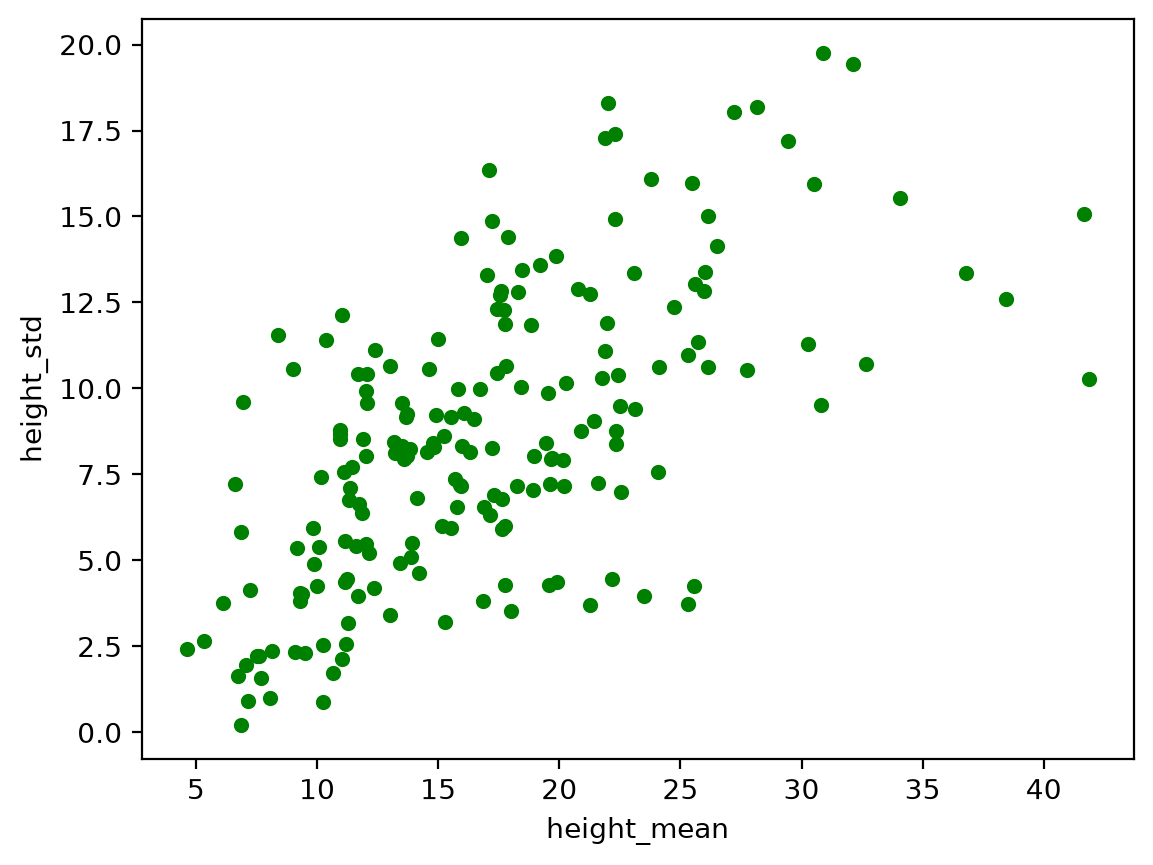

In [12]:
tree_ht_distr_perplot = trees.groupby('plot_id')['height'].agg(['mean', 'std', 'count']).reset_index().rename(columns={'mean':'height_mean', 'std':'height_std', 'count':'height_count'})
tree_ht_distr_perplot.plot(x='height_mean', y='height_std', kind='scatter', color='green', s=20)

In [ ]:
]

<Axes: >

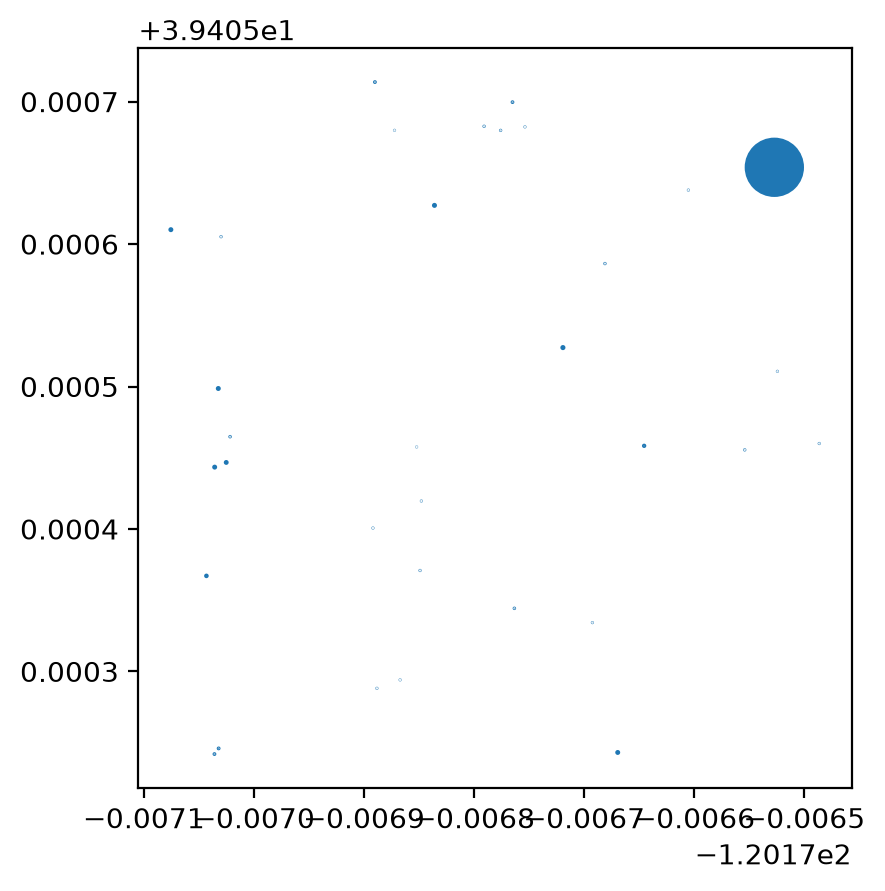

In [109]:
large_ba_plot = plots[plots['basal_area_m2ha']>1000]['plot_id'].iloc[0]
trees[trees['plot_id']==large_ba_plot].plot(markersize='basal_area')

In [113]:
# look at this one: does it actually have a tree with 22m dbh? or is it data entry error?

In [112]:
trees[trees['plot_id']==large_ba_plot].dbh.describe()

count    33.000000
mean      1.083887
std       3.938401
min       0.124460
25%       0.162560
50%       0.241300
75%       0.734060
max      22.961600
Name: dbh, dtype: float64

In [41]:
trees.groupby('plot_id')['dbh'].mean().describe()

count    276.000000
mean       0.327480
std        0.154947
min        0.029667
25%        0.245983
50%        0.311844
75%        0.382691
max        1.083887
Name: dbh, dtype: float64

In [116]:
trees[trees.dbh>5]

,plot_id,subplot_id,height,height_allometric,height_above_plot_center,dbh,species_code,growth_form,live_dead,crown_position,...,decay_class,damage_1,damage_2,damage_3,damage_4,damage_5,contributor_tree_id,notes,geometry,basal_area
334,0018,NaN,7.6200,NaN,NaN,22.9616,PIJE,tree,L,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,POINT (-120.17653 39.40565),414.089109
3890,0006,NaN,29.8704,NaN,NaN,6.8580,ABMA,tree,L,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-120.66953 39.59384),36.938944
46375,0108,NaN,41.1480,NaN,NaN,8.9408,PSME,tree,L,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,95,NaN,POINT (-120.95062 39.49504),62.783030


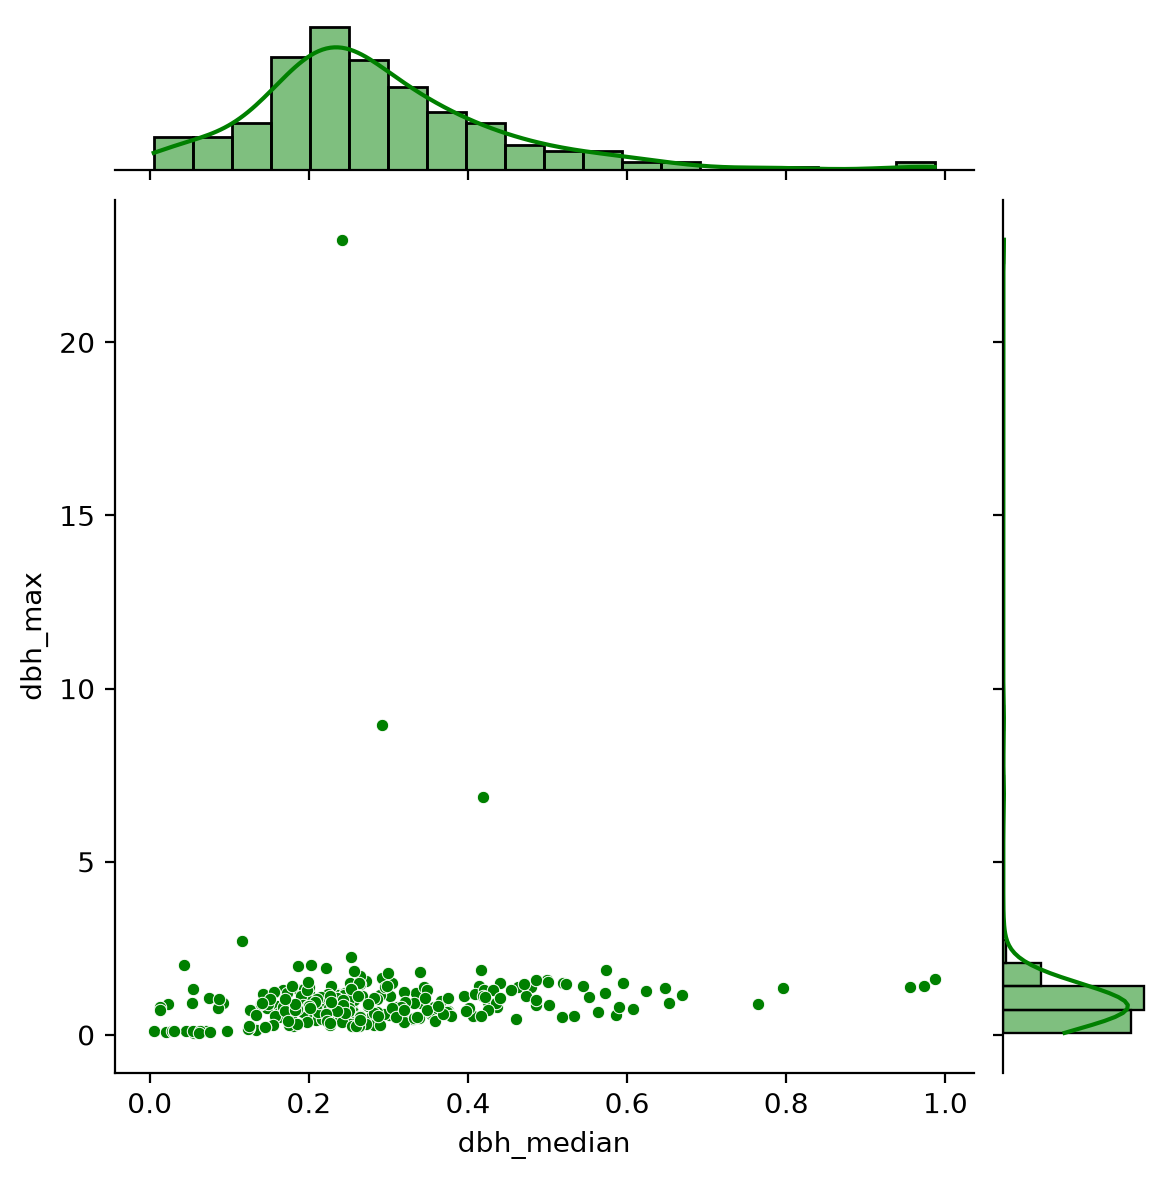

In [115]:
tree_dbh_distr_perplot = trees.groupby('plot_id')['dbh'].agg(['median', 'std', 'count','max']).reset_index().rename(columns={'median':'dbh_median', 'std':'dbh_std', 'count':'dbh_count', 'max':'dbh_max'})
# tree_dbh_distr_perplot.plot(x='dbh_mean', y='dbh_std', kind='scatter', color='green', s=20)

sns.jointplot(data=tree_dbh_distr_perplot, x='dbh_median', y='dbh_max', kind='scatter', color='green', s=20,marginal_kws=dict(kde=True),  )

In [123]:
# binary classification of plots having trees over a specific dbh threshold:
{d:(tree_dbh_distr_perplot['dbh_max']>d).mean().round(3) for d in (1,1.5, 2,2.5, 3,4)}

{1: np.float64(0.36),
 1.5: np.float64(0.091),
 2: np.float64(0.024),
 2.5: np.float64(0.014),
 3: np.float64(0.01),
 4: np.float64(0.01)}

In [93]:
plots[plots['basal_area_m2ha']>1000][['plot_area_ha']]

,plot_area_ha
90,0.291864


<Axes: xlabel='basal_area_m2ha', ylabel='Count'>

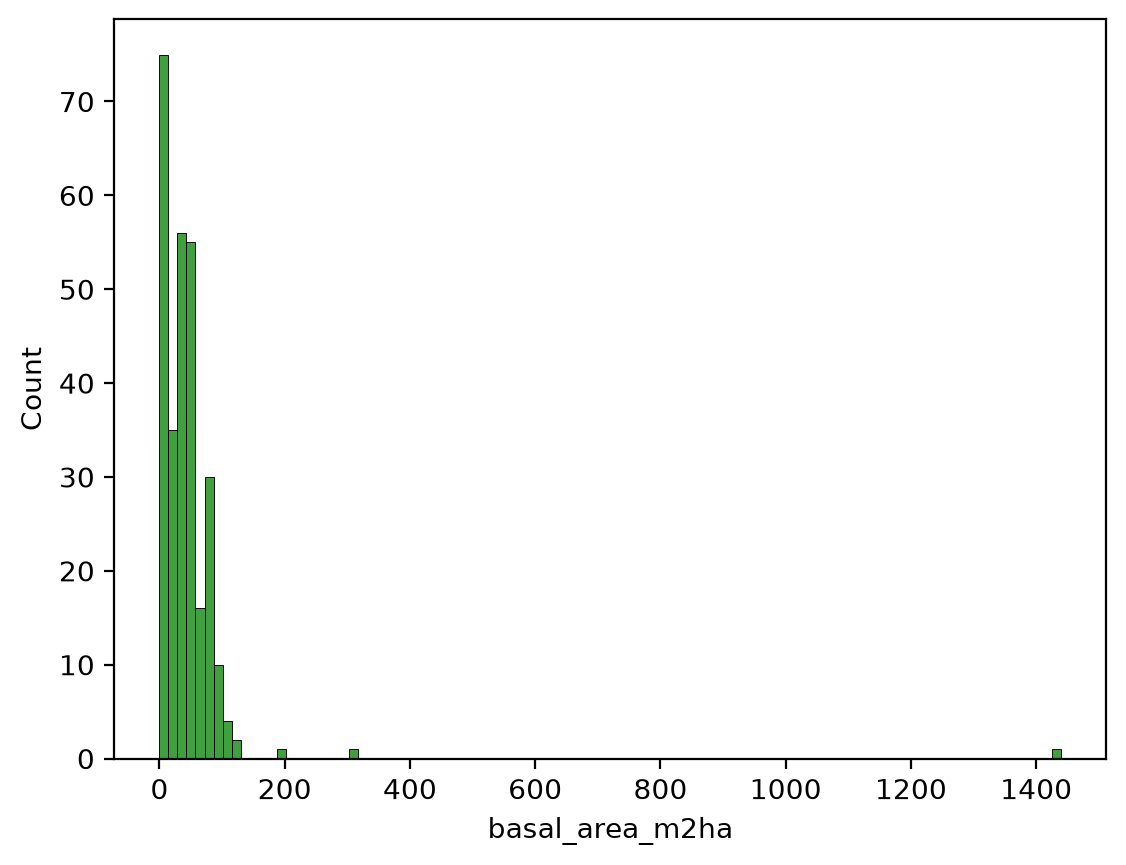

In [91]:
sns.histplot(data=plots, x='basal_area_m2ha', bins=100, color='green')

<Axes: xlabel='plot_area_ha', ylabel='Density'>

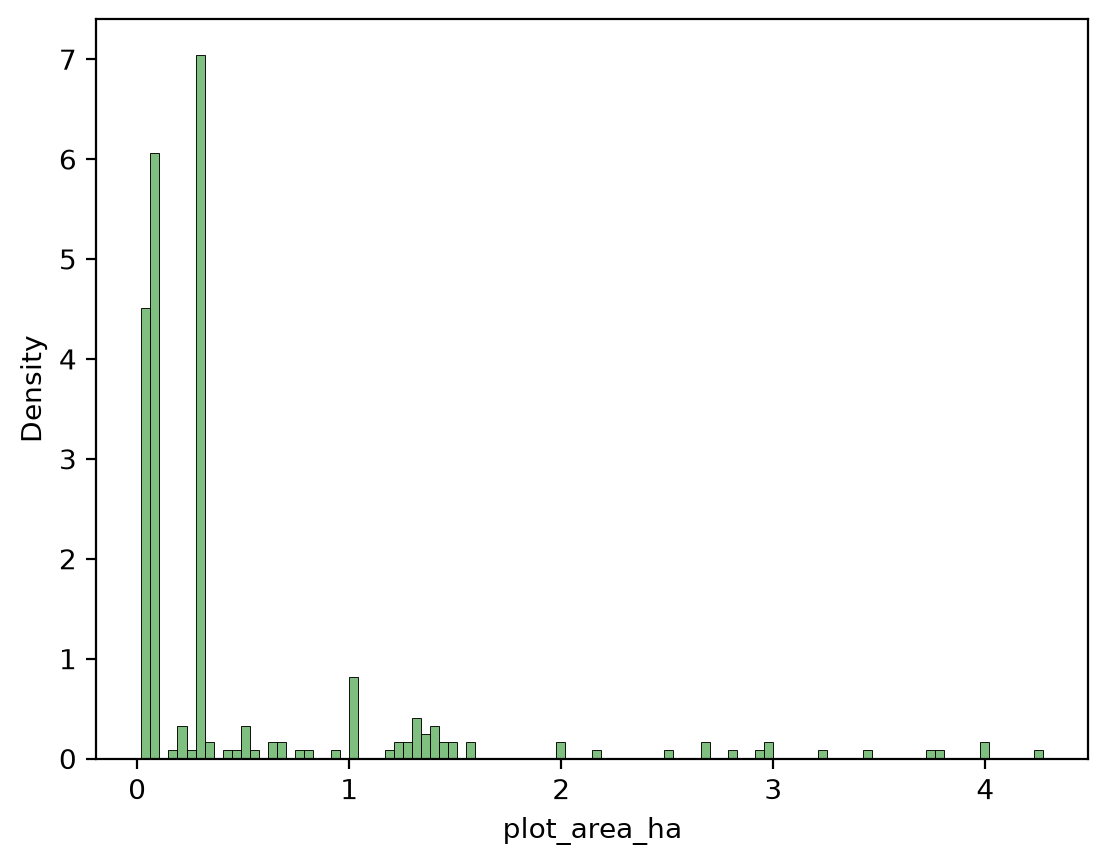

In [95]:
sns.histplot(data=plots, x='plot_area_ha', bins=100, color='green', alpha=0.5, stat='density')

<Axes: >

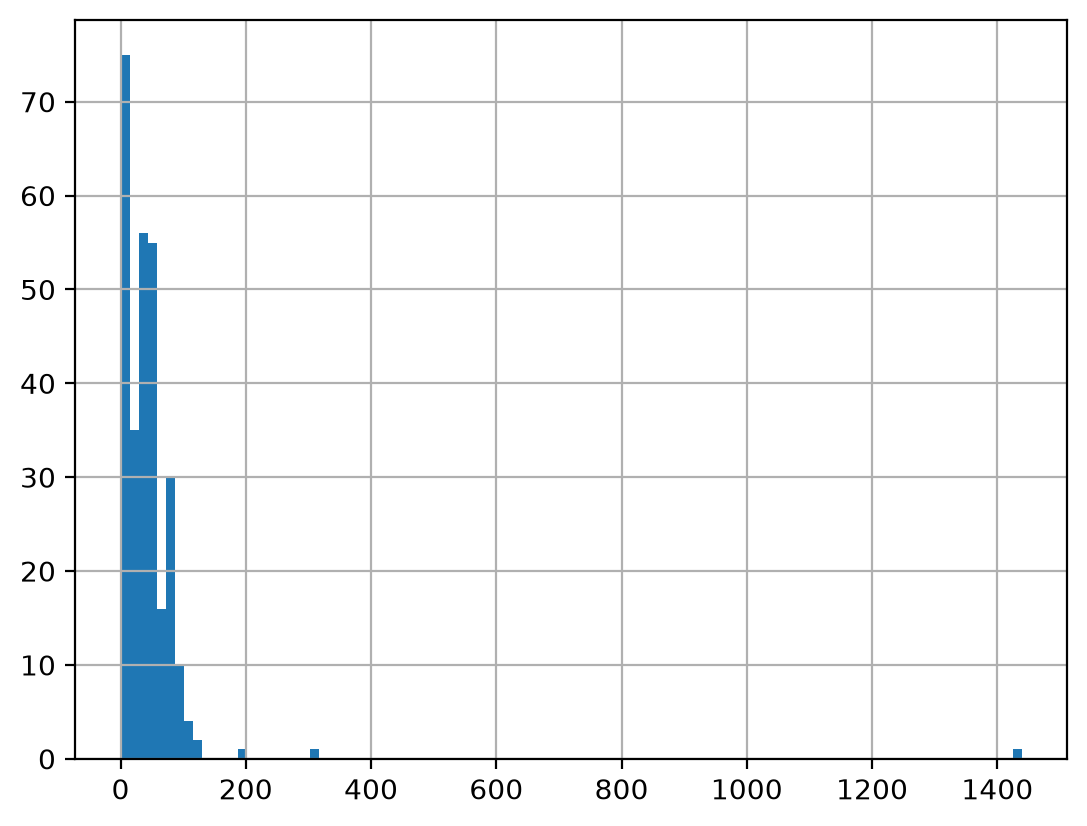

In [60]:
# calculate basal area per plot
trees['basal_area'] = 3.14159 * (trees['dbh']/2)**2
basal_area_per_plot = trees.groupby('plot_id')['basal_area'].sum().rename('basal_area_sum')#.reset_index()
plots['basal_area_m2ha']=plots.join(basal_area_per_plot, on='plot_id')['basal_area_sum'] / plots['plot_area_ha']
# basal_area_per_plot
plots['basal_area_m2ha'].hist(bins=100)

In [61]:
plot_sp_counts = trees.groupby(['plot_id','species_code']).size().unstack()
plot_sp_proportions = plot_sp_counts.div(plot_sp_counts.sum(axis=1), axis=0)
# dictionary of sp:proportion for top 3 sp in each plot
top3_sp_per_plot = plot_sp_proportions.apply(lambda x: x.nlargest(3).round(2).to_dict(), axis=1)
top3_sp_per_plot

plot_id
0001         {'ABCO': 0.71, 'CADE27': 0.13, 'PSME': 0.11}
0002         {'ABCO': 0.71, 'CADE27': 0.18, 'QUKE': 0.08}
0003          {'PSME': 0.54, 'NODE3': 0.16, 'PIPO': 0.12}
0004          {'ABMA': 0.92, 'PICO': 0.06, 'PIMO3': 0.03}
0005          {'ABMA': 0.82, 'PIMO3': 0.17, 'ABCO': 0.01}
                              ...                        
0291             {'PSME': 0.99, 'ACMA3': 0.01, 'AB': nan}
0292    {'CADE27': 0.45, 'PIPJ': 0.42, 'UNK or UNCL': ...
0293    {'ABCO': 0.28, 'UNK or UNCL': 0.27, 'PILA': 0.18}
0294         {'ABCO': 0.39, 'CADE27': 0.22, 'PIPJ': 0.17}
0295    {'UNK or UNCL': 0.38, 'CADE27': 0.19, 'ABCO': ...
Length: 286, dtype: object

In [65]:
plots['plot_id']

0      0070
1      0081
2      0084
3      0071
4      0072
       ... 
282    0251
283    0252
284    0253
285    0254
286    0255
Name: plot_id, Length: 287, dtype: str

<Axes: xlabel='proportion', ylabel='common_name'>

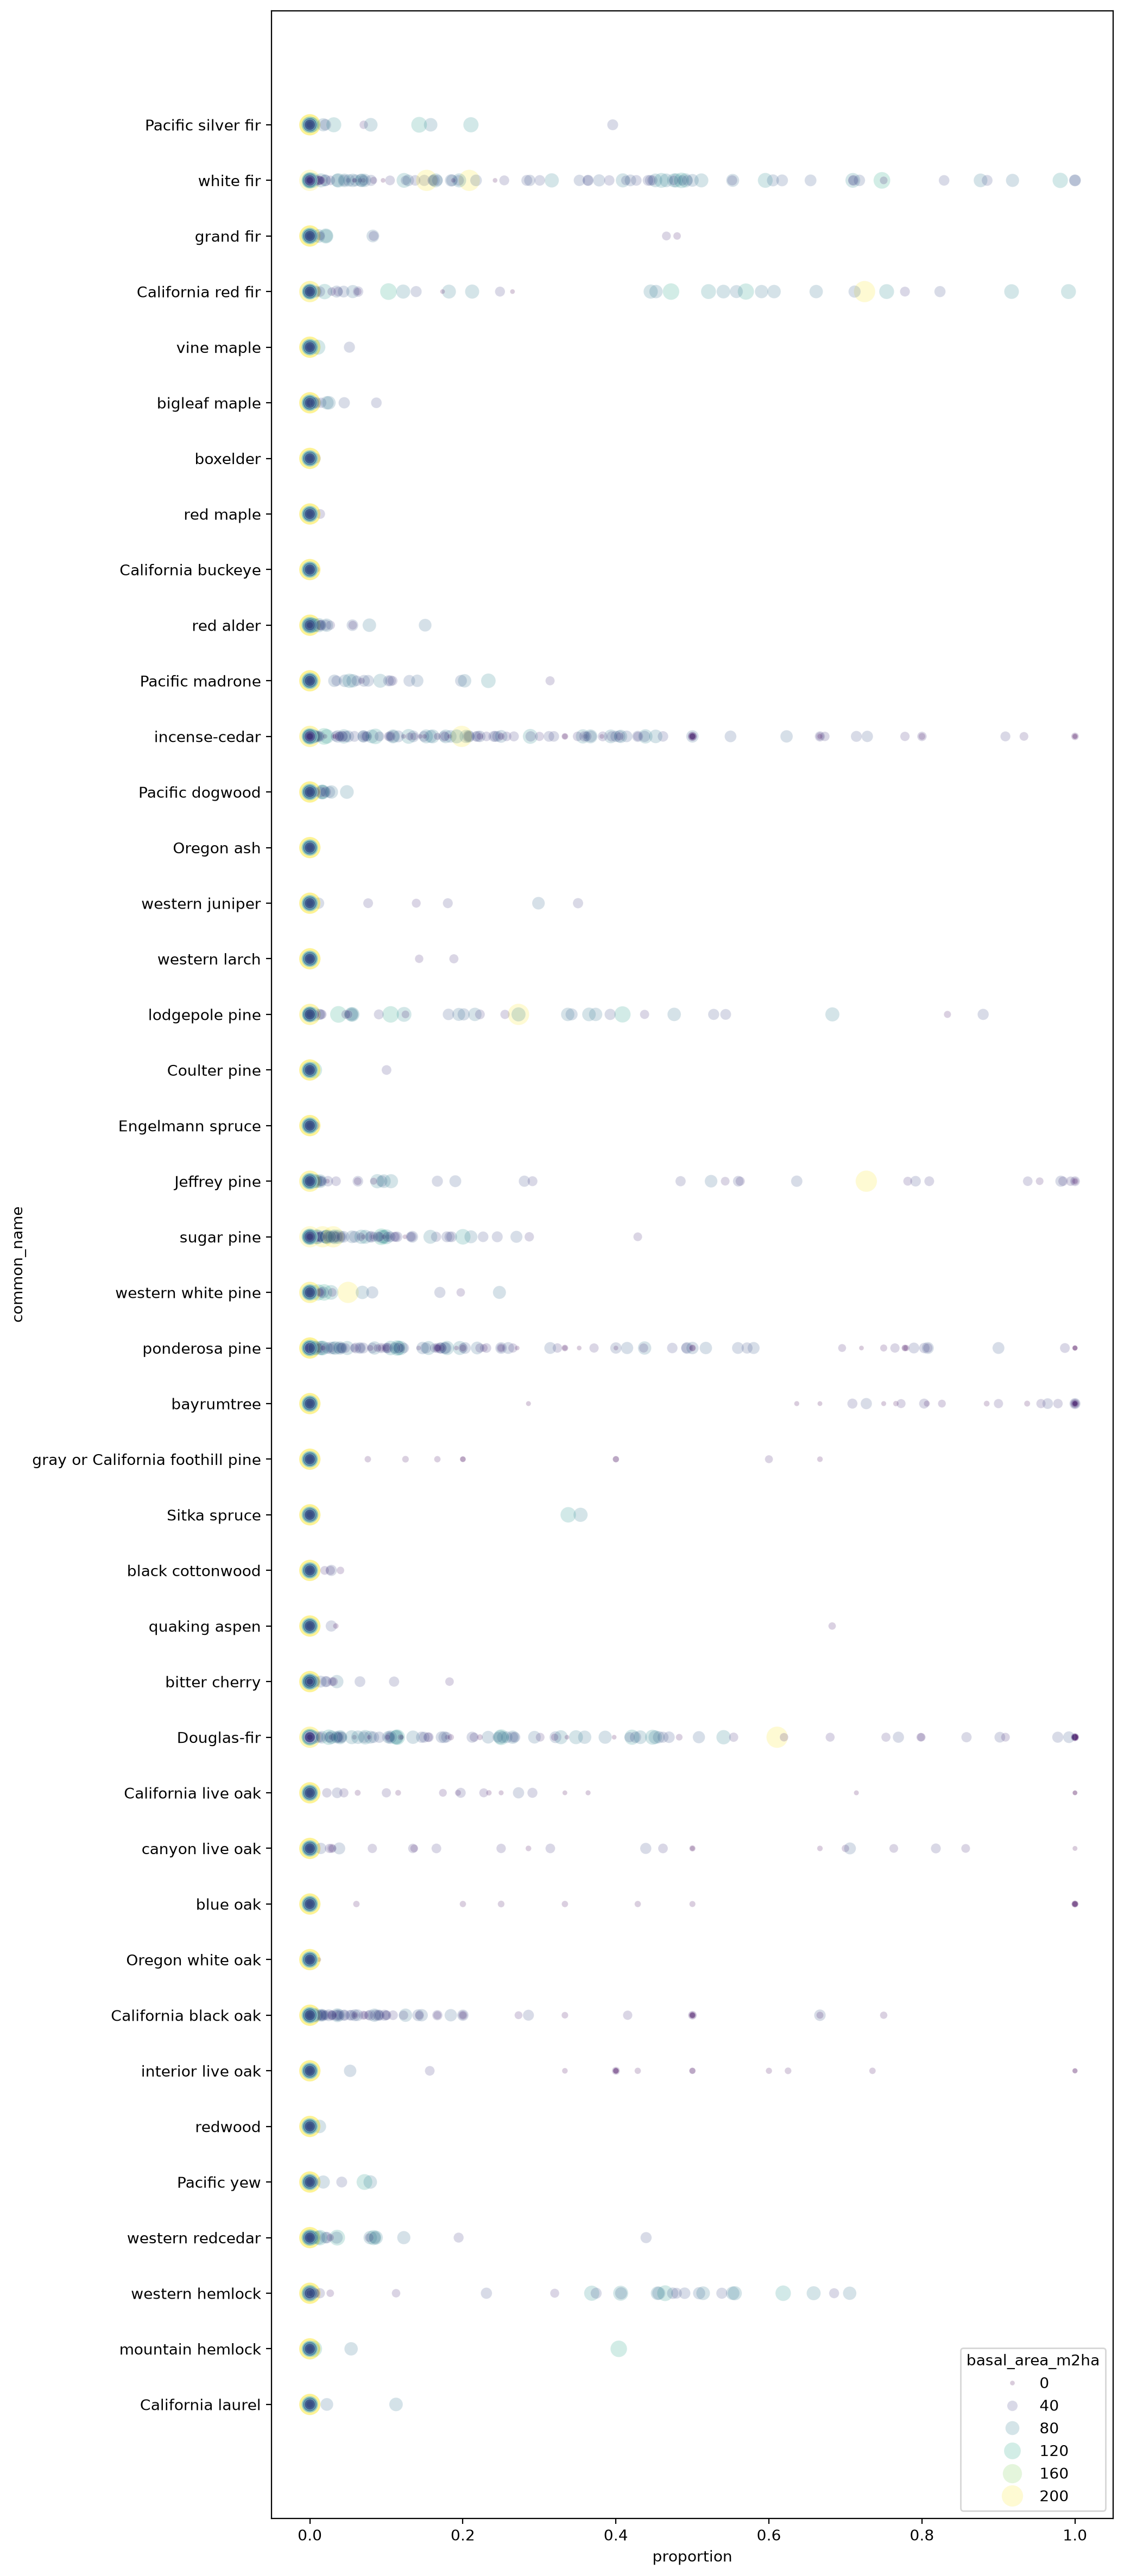

In [68]:
# visualize plot_sp_proportions: one row per sp
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 30))
# add mean plot dbh
records=plot_sp_proportions.reset_index().melt(id_vars='plot_id', var_name='species_code', value_name='proportion').fillna(0)
records['common_name']=records['species_code'].map(code_to_common)
records=records.join(plots.set_index('plot_id')['basal_area_m2ha'].clip(0,200), on='plot_id')

sns.scatterplot(data=records, x='proportion', y='common_name',alpha=0.2,ax=ax, hue='basal_area_m2ha', palette='viridis', size='basal_area_m2ha', sizes=(10, 200))
# records

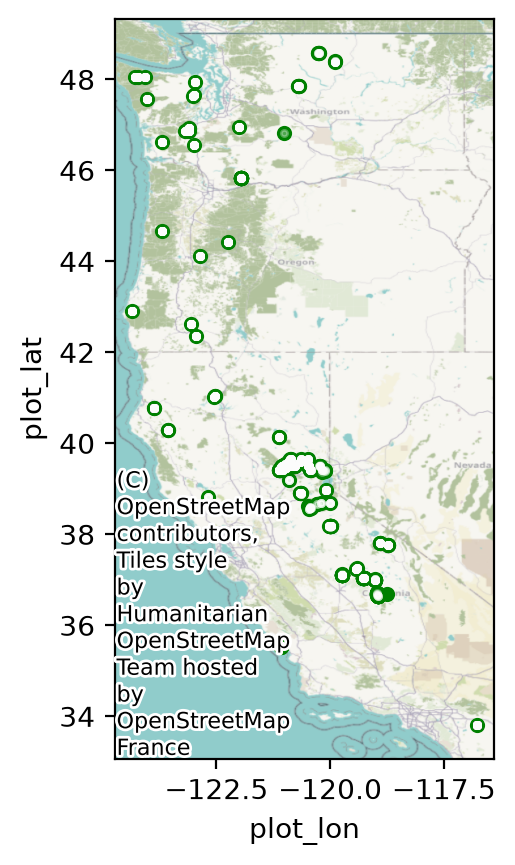

In [ ]:
ax=plots.plot(x='plot_lon', y='plot_lat', kind='scatter',color='green')
trees.sample(3000).plot(alpha=0.3,markersize=5,ax=ax,color='white')

ctx.add_basemap(ax, crs=plots.crs.to_string())
# equal axes no stretching
ax.set_aspect('equal')

# check lidar availability per plot

In [ ]:
import sys
sys.path.append('../src/streaming/3dep/')
from get_als import get_nearest_year_product

Signature:       get_nearest_year_product(lat, lon, year, source='AWS')
Call signature:  get_nearest_year_product(*args, **kwargs)
Type:            _lru_cache_wrapper
String form:     <functools._lru_cache_wrapper object at 0x343619430>
File:            ~/Library/CloudStorage/OneDrive-UCB-O365/Documents/EAGLE/src/streaming/3dep/get_als.py
Docstring:      
Get the nearest 3DEP product for a given latitude, longitude, and year.

Parameters:
lat (float): Latitude of the point (CRS: EPSG:4326).
lon (float): Longitude of the point (CRS: EPSG:4326).
year (int): Year to find the nearest product.

Returns:
pd.Series: A Series containing the nearest 3DEP LAS data product information,
or None if no products are found.
Class docstring:
Create a cached callable that wraps another function.

user_function:      the function being cached

maxsize:  0         for no caching
          None      for unlimited cache size
          n         for a bounded cache

typed:    False     cache f(3) and f(3.0) 

In [ ]:
plots['survey_year']=plots['survey_date'].astype('str').str[:4].astype('int')
plots['survey_year'].value_counts().sort_index()

survey_year
2007     1
2008     2
2013     6
2014     1
2015    42
2016     4
2017    14
2018    16
2019     8
2020     8
2021    50
2022    91
2023    40
2025     4
Name: count, dtype: int64

In [143]:
def find(row):
    try:
        result = get_nearest_year_product(row['plot_lat'], row['plot_lon'], row['survey_year'])
        assert result is not None, "No product found"
        return result
    except Exception as e:
        return {'product_name_AWS': None, 'collection_year_AWS': None, 'year_diff_AWS': None}

In [146]:
vals= plots.apply(find, axis=1, result_type='expand')
plots=plots.join(vals,how='left')

In [ ]:
# 10% of plots no als data

In [149]:
plots.year_diff_AWS.isna().mean()

np.float64(0.0975609756097561)

In [157]:
# 68% of plots have ALS data within 3 years of survey year

In [156]:
(plots.year_diff_AWS.fillna(100)<=3).mean()

np.float64(0.686411149825784)

In [159]:
# when we decide what to predict on each plot, add those aggregated values into the table and re-run this notebook

In [160]:
plots_w_als = plots[plots.year_diff_AWS.fillna(100)<=3]
plots_w_als.to_file('../datasets/OFO_trees/plots_w_als.gpkg')